In [1]:
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# for the tensorpac function
import urllib
from scipy.io import loadmat
from tensorpac import Pac, EventRelatedPac, PreferredPhase
from tensorpac.utils import PeakLockedTF, PSD, ITC, BinAmplitude

sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1, rc={"lines.linewidth": 2, "axes.linewidth":2, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 5, "ytick.major.size": 5})

rc_pub={'font.size': 15, 'axes.labelsize': 15, 'legend.fontsize': 15, 
    'axes.titlesize': 15, 'xtick.labelsize': 15, 'ytick.labelsize': 15, 
    'axes.linewidth':2, 'lines.linewidth': 2,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

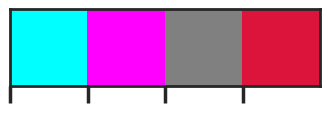

In [3]:
pal=sns.blend_palette(['cyan','magenta','grey','crimson'],4)
sns.palplot(pal)
sns.set_palette(pal)

---

# Load some necessary variables

In [4]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1000)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1000-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1000-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 210.0 90.0 150.0


In [5]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

# Load previous saved PAC arrays

In [7]:
rew_wt = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\wt_hpc1_rew.npy")
rew_fx = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\fx_hpc1_rew.npy")

rew2_wt = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\wt_hpc1_rew2.npy")
rew2_fx = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\fx_hpc1_rew2.npy")

unrew_wt = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\wt_hpc1_unrew.npy")
unrew_fx = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\fx_hpc1_unrew.npy")

novel_wt = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\wt_hpc1_novel.npy")
novel_fx = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\fx_hpc1_novel.npy")

In [8]:
print('Rewarded with water arrays (wt & fx)')
print(rew_wt.shape)
print(rew_fx.shape)
print('Rewarded without water arrays (wt & fx)')
print(rew2_wt.shape)
print(rew2_fx.shape)
print('Unrewarded arrays (wt & fx)')
print(unrew_wt.shape)
print(unrew_fx.shape)
print('Novel arrays (wt & fx)')
print(novel_wt.shape)
print(novel_fx.shape)

Rewarded with water arrays (wt & fx)
(10, 80, 7350)
(8, 80, 7350)
Rewarded without water arrays (wt & fx)
(10, 20, 7350)
(8, 20, 7350)
Unrewarded arrays (wt & fx)
(10, 50, 7350)
(8, 50, 7350)
Novel arrays (wt & fx)
(10, 49, 7350)
(6, 49, 7350)


---

# PAC analysis for all mice in each group
- TensorPAC documentation here: https://etiennecmb.github.io/tensorpac/api.html#utility-functions

In [9]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sf = 2500                                             # sampling frequency
times = np.linspace(0, samples_tr/sf, samples_tr)     # time vector

In [10]:
def PAC_group_analysis(mouse_array, p_obj, t_arr, sf=2500, times=np.linspace(0, samples_tr/sf, samples_tr)):
    # extract all of the phases and amplitudes
    pha_p = p_obj.filter(sf, mouse_array, ftype='phase')
    amp_p = p_obj.filter(sf, mouse_array, ftype='amplitude')
    # define time indices where oscillations
    t1 = int(t_arr[0]*2500)
    t2 = int(t_arr[1]*2500)
    time_2 = slice(t1, t2)
    # define phase / amplitude during oscillation
    pha_2, amp_2 = pha_p[..., time_2], amp_p[..., time_2]
    # compute PAC inside oscillation
    pac_2 = p_obj.fit(pha_2, amp_2).mean(-1)
    return pac_2

def group_avg_PAC(group_array, p_obj, t_arr):
    all_pac_2 = []
    #loop through individual mice to create PAC array with "PAC_group_analysis" function above
    for mouse in range(group_array.shape[0]):
        print('Mouse {}'.format(mouse))
        foo_arr = group_array[mouse]
        try:
            pac_2 = PAC_group_analysis(foo_arr, p_obj, t_arr)
            #append individual mice to group list
            all_pac_2.append(pac_2)
        except:
            print('Problem with mouse {}'.format(mouse))
    #convert lists to numpy.arrays    
    all_pac_2=np.array(all_pac_2)
    return all_pac_2

## Explanation for the below p_obj
Here are the various methods of calculating the values (relates to idpac=(x,0,0) variable)
1. Mean Vector Length (MVL)
2. Modulation Index (MI)
3. Heights Ratio (HR)
4. ndPAC
5. Phase-Locking value (PLV)
6. Gaussian Copula PAC (GCPAC)

In [11]:


p_obj = Pac(idpac=(6, 0, 0), f_pha=(4, 8, 0.5, .1), f_amp=(30, 70, 2, 1)) #(start, stop, width, step)

tim_arr = [0.5,1.2]
tim_arr_sp = [2.2,2.6]



Phase Amplitude Coupling object defined


In [12]:
# rewarded with water situation
print('~~~~~~~~~~ Rewarded with Water ~~~~~~~~~~')
all_rew_wt = group_avg_PAC(rew_wt, p_obj, t_arr=tim_arr)
all_rew_fx = group_avg_PAC(rew_fx, p_obj, t_arr=tim_arr)
#average the numpy.arrays across all mice in the group
mid_rew_wt = np.mean(all_rew_wt, axis=0)
mid_rew_fx = np.mean(all_rew_fx, axis=0)

# rewarded without water situation
print('~~~~~~~~~~ Rewarded without Water ~~~~~~~~~~')
all_rew2_wt = group_avg_PAC(rew2_wt, p_obj, t_arr=tim_arr)
all_rew2_fx = group_avg_PAC(rew2_fx, p_obj, t_arr=tim_arr)
#average the numpy.arrays across all mice in the group
mid_rew2_wt = np.mean(all_rew2_wt, axis=0)
mid_rew2_fx = np.mean(all_rew2_fx, axis=0)

# unrewarded situation
print('~~~~~~~~~~ Unrewarded ~~~~~~~~~~')
all_unrew_wt = group_avg_PAC(unrew_wt, p_obj, t_arr=tim_arr)
all_unrew_fx = group_avg_PAC(unrew_fx, p_obj, t_arr=tim_arr)
#average the numpy.arrays across all mice in the group
mid_unrew_wt = np.mean(all_unrew_wt, axis=0)
mid_unrew_fx = np.mean(all_unrew_fx, axis=0)

# novel situation
print('~~~~~~~~~~ Novel ~~~~~~~~~~')
all_novel_wt = group_avg_PAC(novel_wt, p_obj, t_arr=tim_arr)
all_novel_fx = group_avg_PAC(novel_fx, p_obj, t_arr=tim_arr)
#average the numpy.arrays across all mice in the group
mid_novel_wt = np.mean(all_novel_wt, axis=0)
mid_novel_fx = np.mean(all_novel_fx, axis=0)

~~~~~~~~~~ Rewarded with Water ~~~~~~~~~~
Mouse 0


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 1


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 2


...

    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 4


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 5


    true PAC estimation using Gaussian Copula PAC (gcPac)


## Remove spontaneous background noise

In [13]:
# rewarded with water situation
print('~~~~~~~~~~ Rewarded with Water ~~~~~~~~~~')
sp_all_rew_wt = group_avg_PAC(rew_wt, p_obj, t_arr=tim_arr_sp)
sp_all_rew_fx = group_avg_PAC(rew_fx, p_obj, t_arr=tim_arr_sp)
#average the numpy.arrays across all mice in the group
sp_mid_rew_wt = np.mean(sp_all_rew_wt, axis=0)
sp_mid_rew_fx = np.mean(sp_all_rew_fx, axis=0)

# rewarded without water situation
print('~~~~~~~~~~ Rewarded without Water ~~~~~~~~~~')
sp_all_rew2_wt = group_avg_PAC(rew2_wt, p_obj, t_arr=tim_arr_sp)
sp_all_rew2_fx = group_avg_PAC(rew2_fx, p_obj, t_arr=tim_arr_sp)
#average the numpy.arrays across all mice in the group
sp_mid_rew2_wt = np.mean(sp_all_rew2_wt, axis=0)
sp_mid_rew2_fx = np.mean(sp_all_rew2_fx, axis=0)

# unrewarded situation
print('~~~~~~~~~~ Unrewarded ~~~~~~~~~~')
sp_all_unrew_wt = group_avg_PAC(unrew_wt, p_obj, t_arr=tim_arr_sp)
sp_all_unrew_fx = group_avg_PAC(unrew_fx, p_obj, t_arr=tim_arr_sp)
#average the numpy.arrays across all mice in the group
sp_mid_unrew_wt = np.mean(sp_all_unrew_wt, axis=0)
sp_mid_unrew_fx = np.mean(sp_all_unrew_fx, axis=0)

# novel situation
print('~~~~~~~~~~ Novel ~~~~~~~~~~')
sp_all_novel_wt = group_avg_PAC(novel_wt, p_obj, t_arr=tim_arr_sp)
sp_all_novel_fx = group_avg_PAC(novel_fx, p_obj, t_arr=tim_arr_sp)
#average the numpy.arrays across all mice in the group
sp_mid_novel_wt = np.mean(sp_all_novel_wt, axis=0)
sp_mid_novel_fx = np.mean(sp_all_novel_fx, axis=0)

~~~~~~~~~~ Rewarded with Water ~~~~~~~~~~
Mouse 0


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 1


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 2


...

    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 4


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 5


    true PAC estimation using Gaussian Copula PAC (gcPac)


In [14]:
#subtract the oscillation PAC with the spontaneous PAC
mid2_rew_wt = abs(mid_rew_wt - sp_mid_rew_wt)
mid2_rew2_wt = abs(mid_rew2_wt - sp_mid_rew2_wt)
mid2_unrew_wt = abs(mid_unrew_wt - sp_mid_unrew_wt)
mid2_novel_wt = abs(mid_novel_wt - sp_mid_novel_wt)

mid2_rew_fx = abs(mid_rew_fx - sp_mid_rew_fx)
mid2_rew2_fx = abs(mid_rew2_fx - sp_mid_rew2_fx)
mid2_unrew_fx = abs(mid_unrew_fx - sp_mid_unrew_fx)
mid2_novel_fx = abs(mid_novel_fx - sp_mid_novel_fx)


# Normalize the arrays
There's different ways of normalizing it
1. normalize across each __situation__ against both __groups__ ("norm_situation)
2. normalize across each __group__ against both __situations__ ("norm_group")
3. normalize across all __groups__ and __situations__ ("norm_all")

In [15]:
def norm_situation(wt_array, fx_array):
    max_max = np.max([wt_array.max(), fx_array.max()])
    out_wt = wt_array/max_max
    out_fx = fx_array/max_max
    return out_wt, out_fx

def norm_group(array1, array2, array3, array4):
    max_max = np.max([array1.max(), array2.max(), array3.max(), array4.max()])
    out1 = array1/max_max
    out2 = array2/max_max
    out3 = array3/max_max
    out4 = array4/max_max
    return out1, out2, out3, out4

def norm_all(wtarray1, wtarray2, wtarray3, wtarray4, fxarray1, fxarray2, fxarray3, fxarray4):
    max_max = np.max([wtarray1.max(), wtarray2.max(), wtarray3.max(), wtarray4.max(), 
                      fxarray1.max(), fxarray2.max(), fxarray3.max(), fxarray4.max()])
    wtout1 = wtarray1/max_max
    wtout2 = wtarray2/max_max
    wtout3 = wtarray3/max_max
    wtout4 = wtarray4/max_max
    fxout1 = fxarray1/max_max
    fxout2 = fxarray2/max_max
    fxout3 = fxarray3/max_max
    fxout4 = fxarray4/max_max
    return wtout1, wtout2, wtout3, wtout4, fxout1, fxout2, fxout3, fxout4

#### Normal PAC

In [16]:
## Normalize the situation across groups
# norm_rew_wt, norm_rew_fx = norm_situation(mid_rew_wt, mid_rew_fx)
# norm_rew2_wt, norm_rew2_fx = norm_situation(mid_rew2_wt, mid_rew2_fx)
# norm_unrew_wt, norm_unrew_fx = norm_situation(mid_unrew_wt, mid_unrew_fx)
# norm_novel_wt, norm_novel_fx = norm_situation(mid_novel_wt, mid_novel_fx)

## Normalize the group across situations
norm_rew_wt, norm_rew2_wt, norm_unrew_wt, norm_novel_wt = norm_group(mid_rew_wt, mid_rew2_wt, mid_unrew_wt, mid_novel_wt)
norm_rew_fx, norm_rew2_fx, norm_unrew_fx, norm_novel_fx = norm_group(mid_rew_fx, mid_rew2_fx, mid_unrew_fx, mid_novel_fx)

## Normalize everything together
# norm_rew_wt, norm_rew2_wt, norm_unrew_wt, norm_novel_wt, norm_rew_fx, norm_rew2_fx, norm_unrew_fx, norm_novel_fx = norm_all(mid_rew_wt, mid_rew2_wt, mid_unrew_wt, mid_novel_wt, 
#                                                                                                                             mid_rew_fx, mid_rew2_fx, mid_unrew_fx, mid_novel_fx)



#### Spontaneous activity removed PAC

In [17]:
## Normalize the situation across groups
# norm_rew_wt, norm_rew_fx = norm_situation(mid2_rew_wt, mid2_rew_fx)
# norm_rew2_wt, norm_rew2_fx = norm_situation(mid2_rew2_wt, mid2_rew2_fx)
# norm_unrew_wt, norm_unrew_fx = norm_situation(mid2_unrew_wt, mid2_unrew_fx)
# norm_novel_wt, norm_novel_fx = norm_situation(mid2_novel_wt, mid2_novel_fx)

## Normalize the group across situations
norm_rew_wt, norm_rew2_wt, norm_unrew_wt, norm_novel_wt = norm_group(mid2_rew_wt, mid2_rew2_wt, mid2_unrew_wt, mid2_novel_wt)
norm_rew_fx, norm_rew2_fx, norm_unrew_fx, norm_novel_fx = norm_group(mid2_rew_fx, mid2_rew2_fx, mid2_unrew_fx, mid2_novel_fx)

# Compute the difference between WT & FX

In [18]:
plot_input = 'norm'

if plot_input == 'raw':
#     rew_diff = mid_rew_wt - mid_rew_fx
#     rew2_diff = mid_rew2_wt - mid_rew2_fx
#     unrew_diff = mid_unrew_wt - mid_unrew_fx
#     novel_diff = mid_novel_wt - mid_novel_fx
    rew_diff = mid2_rew_wt - mid2_rew_fx
    rew2_diff = mid2_rew2_wt - mid2_rew2_fx
    unrew_diff = mid2_unrew_wt - mid2_unrew_fx
    novel_diff = mid2_novel_wt - mid2_novel_fx
    rew_diff, rew2_diff, unrew_diff, novel_diff = norm_group(rew_diff, rew2_diff, unrew_diff, novel_diff)
elif plot_input == 'norm':
    rew_diff = norm_rew_wt - norm_rew_fx
    rew2_diff = norm_rew2_wt - norm_rew2_fx
    unrew_diff = norm_unrew_wt - norm_unrew_fx
    novel_diff = norm_novel_wt - norm_novel_fx
    
print(rew_diff.shape)
print(rew2_diff.shape)
print(unrew_diff.shape)
print(novel_diff.shape)

(38, 35)
(38, 35)
(38, 35)
(38, 35)


## Plot PAC to compare WT/FX

In [19]:
if plot_input == 'raw':
#     vmin, vmax = 0.0, np.round(mid_rew_wt.max())
#     vmin1, vmax1 = 0.0, np.round(rew_diff.max())
    vmin, vmax = 0.0, 0.8
    vmin1, vmax1 = 0.0, 0.2
    kw = dict(vmax=vmax, vmin=vmin, cmap='viridis')
    kw00 = dict(vmax=vmax1, vmin=vmin1, cmap='plasma')
    cb_dif = vmax1-vmin1
    cbar_ticks = [(vmin1),(cb_dif/2+vmin1),vmax1]
elif plot_input == 'norm':
#     vmin, vmax = 0.0, round(norm_rew_wt.max(),2)
#     vmin1, vmax1 = 0.0, round(rew_diff.max(),2)
    vmin, vmax = 0.0, 0.8
    vmin1, vmax1 = 0.0, 0.2
    kw = dict(vmax=vmax, vmin=vmin, cmap='viridis')
    kw00 = dict(vmax=vmax1, vmin=vmin1, cmap='plasma')
    cb_dif = vmax1-vmin1
    cbar_ticks = [(vmin1),(cb_dif/2+vmin1),vmax1]
    

In [20]:
if plot_input == 'raw':
    rew1, rew2, rew3 = mid_rew_wt, mid_rew_fx, rew_diff
    rew21, rew22, rew23 = mid_rew2_wt, mid_rew2_fx, rew2_diff
    unrew1, unrew2, unrew3 = mid_unrew_wt, mid_unrew_fx, unrew_diff
    novel1, novel2, novel3 = mid_novel_wt, mid_novel_fx, novel_diff
elif plot_input == 'norm':
    rew1, rew2, rew3 = norm_rew_wt, norm_rew_fx, rew_diff
    rew21, rew22, rew23 = norm_rew2_wt, norm_rew2_fx, rew2_diff
    unrew1, unrew2, unrew3 = norm_unrew_wt, norm_unrew_fx, unrew_diff
    novel1, novel2, novel3 = norm_novel_wt, norm_novel_fx, novel_diff

### Rewarded with Water

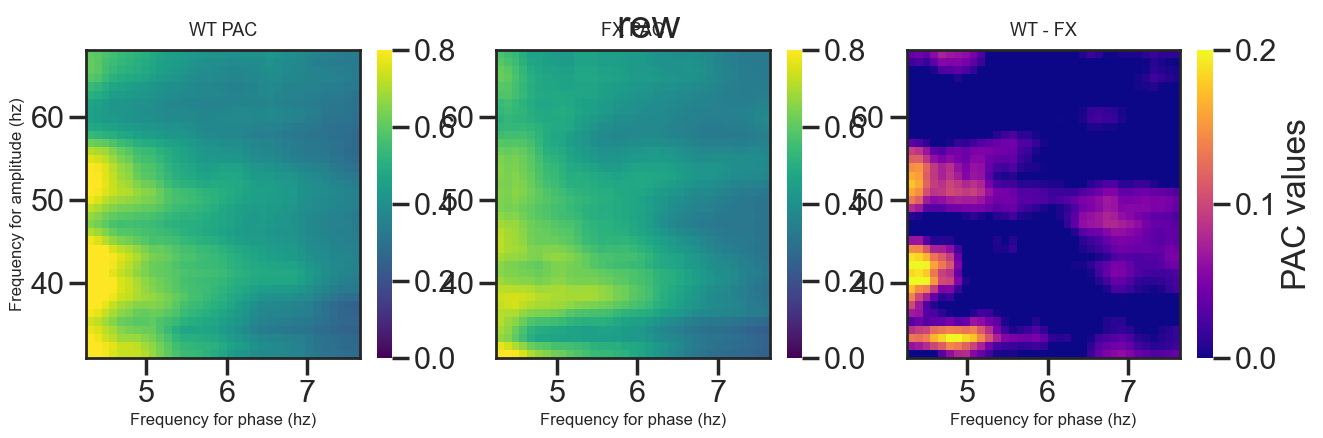

In [21]:
plt.figure(figsize=(15, 4))
plt.suptitle("rew")
ax1=plt.subplot(131)
p_obj.comodulogram(rew1, title="WT PAC", colorbar=False, **kw)
plt.xticks([3,4,5,6,7,8,9])
plt.yticks([30,40,50,60,70,80])
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax2=plt.subplot(132, sharex=ax1, sharey=ax1)
p_obj.comodulogram(rew2, title="FX PAC", colorbar=False, **kw)
plt.ylabel('')
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax3=plt.subplot(133, sharex=ax1, sharey=ax1)
p_obj.comodulogram(rew3, title="WT - FX", colorbar=False, **kw00)
plt.ylabel('')
cbar=plt.colorbar(label='PAC values')
cbar.set_ticks(cbar_ticks)
cbar.outline.set_visible(False)

# Change the end of this next line with a new file name!!
# plt.savefig(r"C:\Users\AChub_Lab\Desktop\temp_hpc_plots\pac\rew_heat.pdf", transparent=True)

plt.show()

### Rewarded without Water

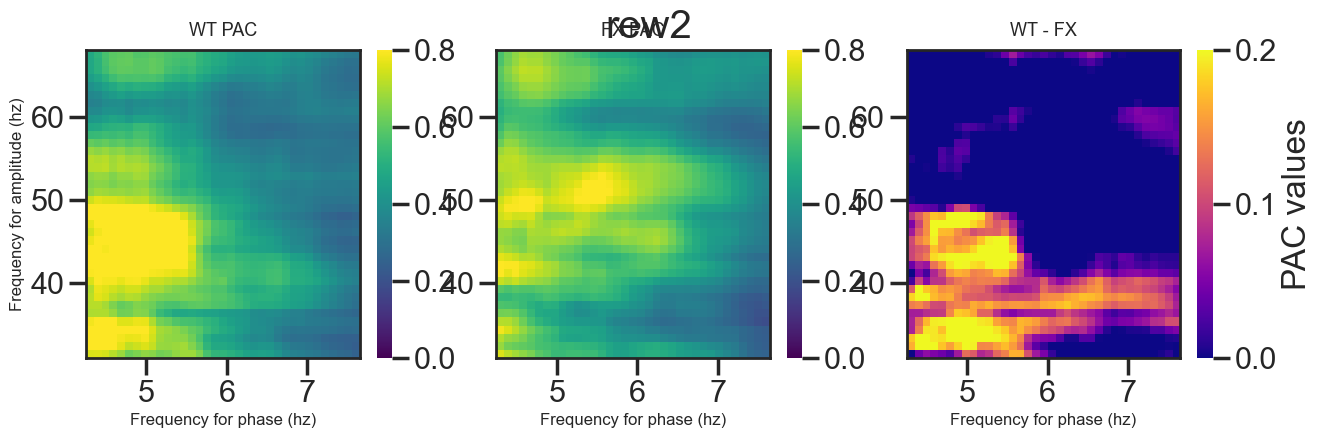

In [22]:
plt.figure(figsize=(15, 4))
plt.suptitle("rew2")
ax1=plt.subplot(131)
p_obj.comodulogram(rew21, title="WT PAC", colorbar=False, **kw)
plt.xticks([3,4,5,6,7,8,9])
plt.yticks([30,40,50,60,70,80])
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax2=plt.subplot(132, sharex=ax1, sharey=ax1)
p_obj.comodulogram(rew22, title="FX PAC", colorbar=False, **kw)
plt.ylabel('')
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax3=plt.subplot(133, sharex=ax1, sharey=ax1)
p_obj.comodulogram(rew23, title="WT - FX", colorbar=False, **kw00)
plt.ylabel('')
cbar=plt.colorbar(label='PAC values')
cbar.set_ticks(cbar_ticks)
cbar.outline.set_visible(False)

# Change the end of this next line with a new file name!!
# plt.savefig(r"C:\Users\AChub_Lab\Desktop\temp_hpc_plots\pac\rew2_heat.pdf", transparent=True)

plt.show()

### Unrewarded

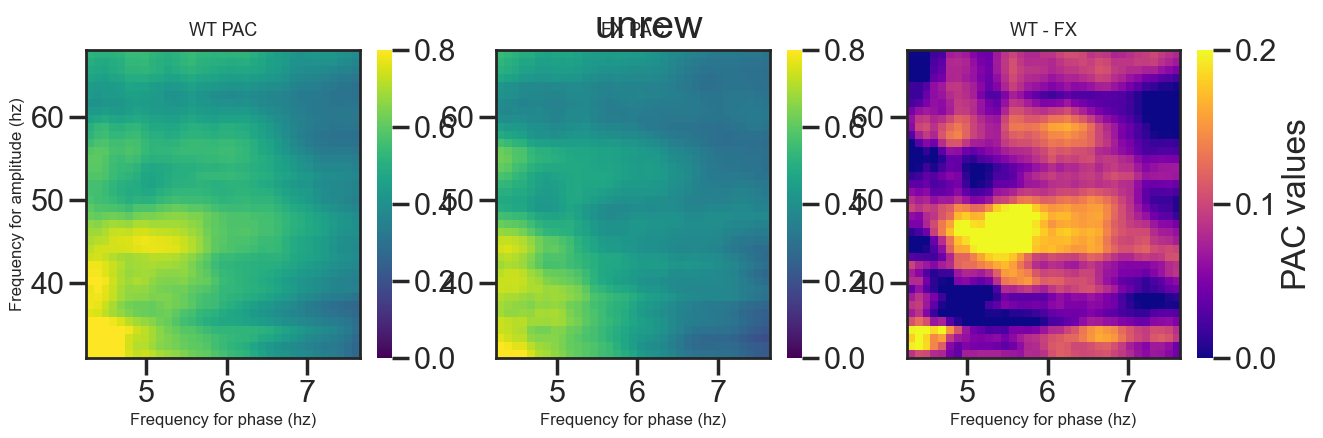

In [23]:
plt.figure(figsize=(15, 4))
plt.suptitle("unrew")
ax1=plt.subplot(131)
p_obj.comodulogram(unrew1, title="WT PAC", colorbar=False, **kw)
plt.xticks([3,4,5,6,7,8,9])
plt.yticks([30,40,50,60,70,80])
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax2=plt.subplot(132, sharex=ax1, sharey=ax1)
p_obj.comodulogram(unrew2, title="FX PAC", colorbar=False, **kw)
plt.ylabel('')
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax3=plt.subplot(133, sharex=ax1, sharey=ax1)
p_obj.comodulogram(unrew3, title="WT - FX", colorbar=False, **kw00)
plt.ylabel('')
cbar=plt.colorbar(label='PAC values')
cbar.set_ticks(cbar_ticks)
cbar.outline.set_visible(False)

# Change the end of this next line with a new file name!!
# plt.savefig(r"C:\Users\AChub_Lab\Desktop\temp_hpc_plots\pac\unrew_heat.pdf", transparent=True)

plt.show()

### Novel

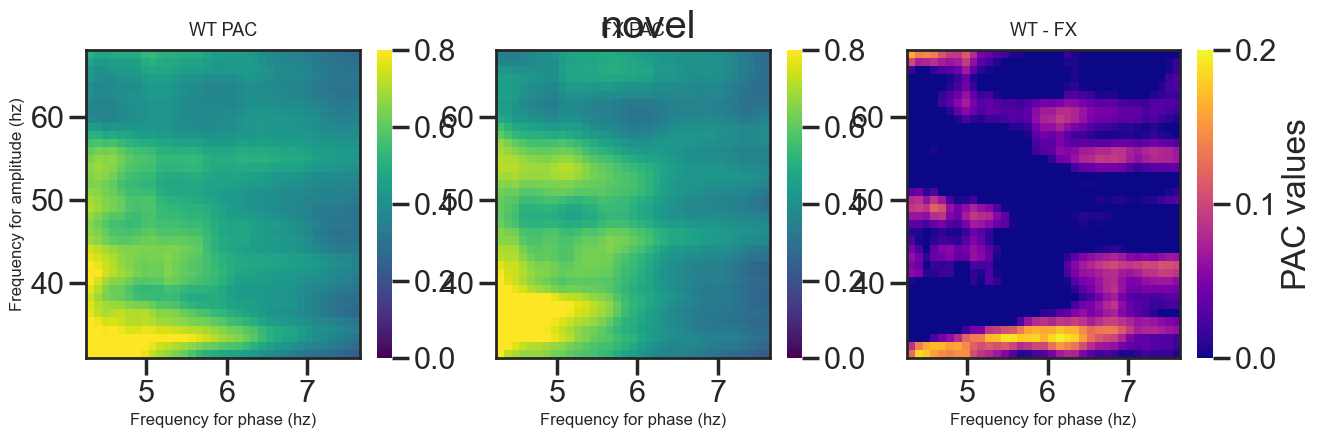

In [24]:
plt.figure(figsize=(15, 4))
plt.suptitle("novel")
ax1=plt.subplot(131)
p_obj.comodulogram(novel1, title="WT PAC", colorbar=False, **kw)
plt.xticks([3,4,5,6,7,8,9])
plt.yticks([30,40,50,60,70,80])
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax2=plt.subplot(132, sharex=ax1, sharey=ax1)
p_obj.comodulogram(novel2, title="FX PAC", colorbar=False, **kw)
plt.ylabel('')
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax3=plt.subplot(133, sharex=ax1, sharey=ax1)
p_obj.comodulogram(novel3, title="WT - FX", colorbar=False, **kw00)
plt.ylabel('')
cbar=plt.colorbar(label='PAC values')
cbar.set_ticks(cbar_ticks)
cbar.outline.set_visible(False)

# Change the end of this next line with a new file name!!
# plt.savefig(r"C:\Users\AChub_Lab\Desktop\temp_hpc_plots\pac\novel_heat.pdf", transparent=True)

plt.show()

In [25]:
# plt.figure(figsize=(15, 15))
# p_obj.comodulogram(novel1, title="WT PAC", colorbar=False, **kw)
# plt.xticks([3,4,5,6,7,8,9])
# plt.yticks([30,40,50,60,70,80])
# plt.show()

---

# Quantify the PAC analysis plots above
Essentially I take the mean PAC for each of the regions of interest (Theta:Gamma, Theta:LowGamma, Theta:HighGamma). My manually counted indices based on the PAC object for p_obj
- tlg = matrix[7:27,2:12].mean()
- thg = matrix[7:27,13:27].mean()
- tg = matrix[7:27,2:27].mean()

And for p_obj = Pac(idpac=(6, 0, 0), f_pha=(3, 9, 0.5, .1), f_amp=(30, 80, 2, 1))
- tlg = matrix[7:48,0:20].mean()
- thg = matrix[7:48,21:48].mean()
- tg = matrix[7:48,0:48].mean()

In [26]:
def quantify_pac(all_pac_array):
    theta_low = []
    theta_high = []
    theta_gamma = []
    for mouse, matrix in enumerate(all_pac_array):
        lg_hg = round(matrix.shape[-1]/2)
        tlg = abs(matrix[:,0:lg_hg].mean())    #manually counted indices from pac array created by p_obj defined earlier
        thg = abs(matrix[:,lg_hg:].mean())
        tg = abs(matrix[:,:].mean())
        theta_low.append(tlg)
        theta_high.append(thg)
        theta_gamma.append(tg)
    tlg_df = pd.DataFrame(zip(theta_low,['tlg']*len(theta_low)), columns=['pac_val','coupling'])
    thg_df = pd.DataFrame(zip(theta_high,['thg']*len(theta_high)), columns=['pac_val','coupling'])
    tg_df = pd.DataFrame(zip(theta_gamma,['tg']*len(theta_gamma)), columns=['pac_val','coupling'])
    combo_df = pd.concat([tlg_df, thg_df, tg_df])
    return combo_df

def quantify_pac_help(wt_array, fx_array, situation):
    df_wt = quantify_pac(wt_array)
    df_wt['group']='wt'
    df_fx = quantify_pac(fx_array)
    df_fx['group']='fx'
    df_pac = pd.concat([df_wt, df_fx])
    df_pac['situ']=situation
    return df_pac

def remove_spontaneous(wt_osc_array, wt_sp_array, fx_osc_array, fx_sp_array, situation):
    wt_array = wt_osc_array - wt_sp_array
    fx_array = fx_osc_array - fx_sp_array
    df_pac = quantify_pac_help(wt_array, fx_array, situation)
    return df_pac

In [27]:
rew_pac = quantify_pac_help(all_rew_wt, all_rew_fx, 'rew')
rew2_pac = quantify_pac_help(all_rew2_wt, all_rew2_fx, 'rew2')
unrew_pac = quantify_pac_help(all_unrew_wt, all_unrew_fx, 'unrew')
novel_pac = quantify_pac_help(all_novel_wt, all_novel_fx, 'novel')

# rew_pac = remove_spontaneous(all_rew_wt, sp_all_rew_wt, all_rew_fx, sp_all_rew_fx, 'rew')
# rew2_pac = remove_spontaneous(all_rew2_wt, sp_all_rew2_wt, all_rew2_fx, sp_all_rew2_fx, 'rew2')
# unrew_pac = remove_spontaneous(all_unrew_wt, sp_all_unrew_wt, all_unrew_fx, sp_all_unrew_fx, 'unrew')
# novel_pac = remove_spontaneous(all_novel_wt, sp_all_novel_wt, all_novel_fx, sp_all_novel_fx, 'novel')

big_pac_df = pd.concat([rew_pac, rew2_pac, unrew_pac, novel_pac])

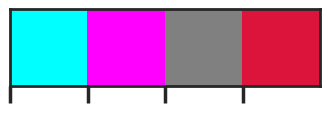

In [28]:
# plt.rcdefaults()
pal=sns.blend_palette(['cyan','magenta','grey','crimson'],4)
sns.palplot(pal)
sns.set_palette(pal)

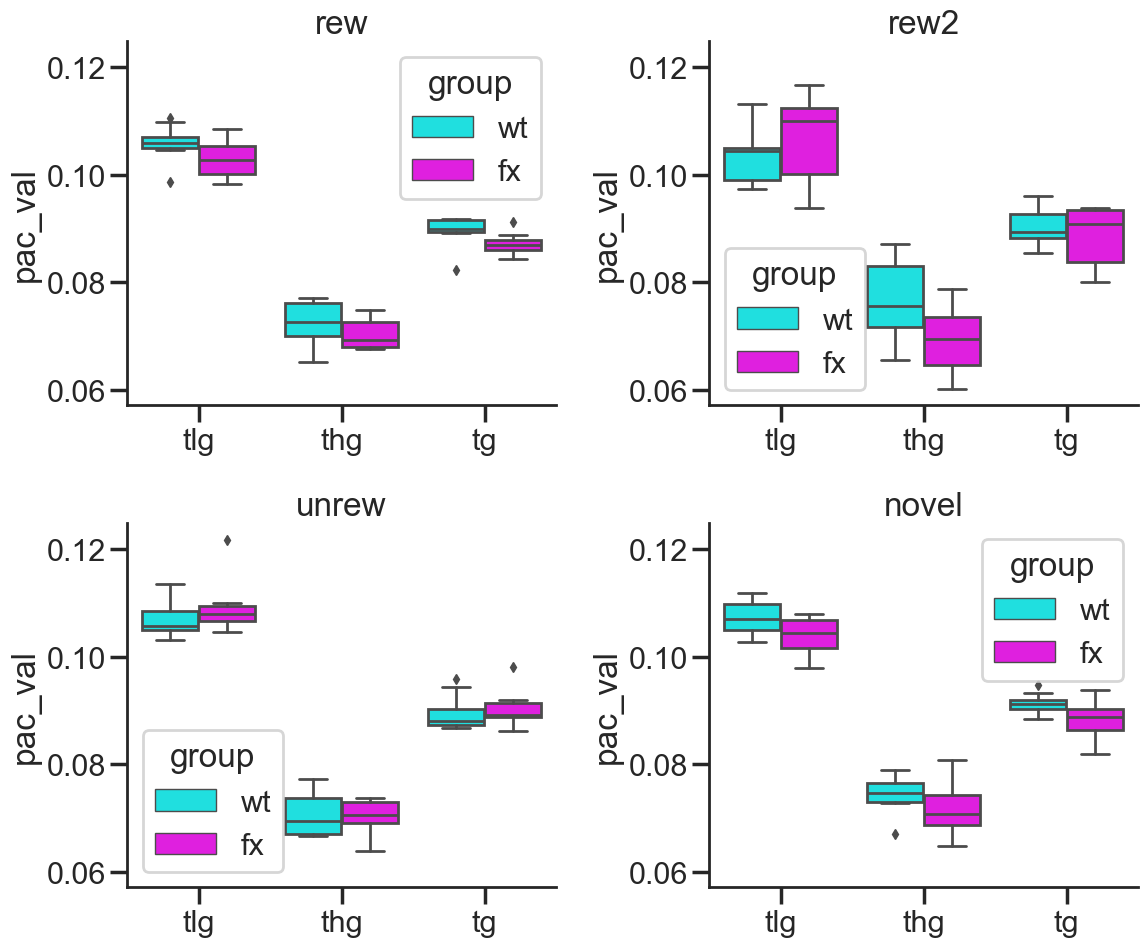

In [32]:
plt.figure(figsize=(12, 10))
ax1=plt.subplot(221)
sns.boxplot(x="coupling", y="pac_val", hue='group', data=rew_pac)#, split=True)
plt.title('rew')
plt.xlabel('')
ax2=plt.subplot(222, sharey=ax1)
sns.boxplot(x="coupling", y="pac_val", hue='group', data=rew2_pac)#, split=True)
plt.title('rew2')
plt.xlabel('')
ax3=plt.subplot(223, sharey=ax1)
sns.boxplot(x="coupling", y="pac_val", hue='group', data=unrew_pac)#, split=True)
plt.title('unrew')
plt.xlabel('')
ax4=plt.subplot(224, sharey=ax1)
sns.boxplot(x="coupling", y="pac_val", hue='group', data=novel_pac)#, split=True)
plt.title('novel')
plt.xlabel('')

sns.despine()
plt.tight_layout()
# Change the end of this next line with a new file name!!
# plt.savefig(r"C:\Users\AChub_Lab\Desktop\temp_hpc_plots\pac\quantify_pac2.pdf", transparent=True)

plt.show()

In [35]:
import scipy.stats as sstat

def pac_stats(situation_df, situation):
    data1 = situation_df[situation_df['group'] == 'wt']
    data2 = situation_df[situation_df['group'] == 'fx']

    varA1 = data1[data1['coupling']=='tlg'].pac_val.values
    varA2 = data1[data1['coupling']=='thg'].pac_val.values
    varA3 = data1[data1['coupling']=='tg'].pac_val.values

    varB1 = data2[data2['coupling']=='tlg'].pac_val.values
    varB2 = data2[data2['coupling']=='thg'].pac_val.values
    varB3 = data2[data2['coupling']=='tg'].pac_val.values

    print('Pac stats --- {0} ---'.format(situation))
    print('tlg: {0}'.format(sstat.mannwhitneyu(varA1, varB1)))
    print('thg: {0}'.format(sstat.mannwhitneyu(varA2, varB2)))
    print('tg: {0}'.format(sstat.mannwhitneyu(varA3, varB3)))
    print('{0} wt & {1} fx mice'.format(len(varA1),len(varB1)))
    print('{0} wt & {1} fx mice'.format(len(varA2),len(varB2)))
    print('{0} wt & {1} fx mice'.format(len(varA3),len(varB3)))
    return

In [36]:
pac_stats(rew_pac, 'rew')
pac_stats(rew2_pac, 'rew2')
pac_stats(unrew_pac, 'unrew')
pac_stats(novel_pac, 'novel')

Pac stats --- rew ---
tlg: MannwhitneyuResult(statistic=57.0, pvalue=0.14221867447100317)
thg: MannwhitneyuResult(statistic=53.0, pvalue=0.26622324487341265)
tg: MannwhitneyuResult(statistic=67.0, pvalue=0.018422231260785786)
10 wt & 8 fx mice
10 wt & 8 fx mice
10 wt & 8 fx mice
Pac stats --- rew2 ---
tlg: MannwhitneyuResult(statistic=28.0, pvalue=0.30637501832228387)
thg: MannwhitneyuResult(statistic=59.0, pvalue=0.09987351755271681)
tg: MannwhitneyuResult(statistic=45.0, pvalue=0.688973304683869)
10 wt & 8 fx mice
10 wt & 8 fx mice
10 wt & 8 fx mice
Pac stats --- unrew ---
tlg: MannwhitneyuResult(statistic=30.0, pvalue=0.39812781090907634)
thg: MannwhitneyuResult(statistic=41.0, pvalue=0.9645281034063854)
tg: MannwhitneyuResult(statistic=28.0, pvalue=0.30637501832228387)
10 wt & 8 fx mice
10 wt & 8 fx mice
10 wt & 8 fx mice
Pac stats --- novel ---
tlg: MannwhitneyuResult(statistic=43.0, pvalue=0.17452283315546124)
thg: MannwhitneyuResult(statistic=42.0, pvalue=0.2115961272345097)
tg:

---

---

---

---

# Identify the preferred phase

In [34]:
def group_pref_phase(mouse_array, sf=2500, phase=[4,8]):
    # define the preferred phase object
    pp_obj = PreferredPhase(f_pha=phase)
    # define time indices where rest, planning and execution are defined
    t1 = int(0.5*sf)
    t2 = int(2.0*sf)
    t3 = int(2.9*sf)
    time_1 = slice(0, t1)
    time_2 = slice(t1, t2)
    time_3 = slice(t2, t3)
    # define the PAC object
    p_obj = Pac(idpac=(6, 0, 0), f_pha=(1, 12, 2, .2), f_amp=(25, 85, 10, 2))
    # extract all of the phases and amplitudes
    pha_p = p_obj.filter(sf, mouse_array, ftype='phase')
    amp_p = p_obj.filter(sf, mouse_array, ftype='amplitude')
    # define phase / amplitude during pre / mid / post
    pha_1, amp_1 = pha_p[..., time_1], amp_p[..., time_1]
    pha_2, amp_2 = pha_p[..., time_2], amp_p[..., time_2]
    pha_3, amp_3 = pha_p[..., time_3], amp_p[..., time_3]
    # only extract the theta phase
    pp_pha = pp_obj.filter(sf, mouse_array, ftype='phase')
    pp_pha_1 = pp_pha[..., time_1]
    pp_pha_2 = pp_pha[..., time_2]
    pp_pha_3 = pp_pha[..., time_3]
    # compute the preferred phase (reuse the amplitude computed above)
    ampbin_1, _, vecbin = pp_obj.fit(pp_pha_1, amp_1, n_bins=72)
    ampbin_2, _, vecbin = pp_obj.fit(pp_pha_2, amp_2, n_bins=72)
    ampbin_3, _, vecbin = pp_obj.fit(pp_pha_3, amp_3, n_bins=72)
    # mean binned amplitude across trials
    ampbin_1 = np.squeeze(ampbin_1).mean(-1).T
    ampbin_2 = np.squeeze(ampbin_2).mean(-1).T
    ampbin_3 = np.squeeze(ampbin_3).mean(-1).T
    
    return ampbin_1, ampbin_2, ampbin_3, vecbin, p_obj

In [35]:
def group_avg_pref_phase(group_array):
    all_pp_1 = []
    all_pp_2 = []
    all_pp_3 = []
    #loop through individual mice to create array with "group_pref_phase" function above
    for mouse in range(group_array.shape[0]):
        print('Mouse {}'.format(mouse))
        foo_arr = group_array[mouse]
        pp_1, pp_2, pp_3, vecbin, p_obj = group_pref_phase(foo_arr)
        #append individual mice to group list
        all_pp_1.append(pp_1)
        all_pp_2.append(pp_2)
        all_pp_3.append(pp_3)
    #convert lists to numpy.arrays    
    all_pp_1=np.array(all_pp_1)
    all_pp_2=np.array(all_pp_2)
    all_pp_3=np.array(all_pp_3)
    #average the numpy.arrays across all mice in the group
    avg_pp_1 = np.mean(all_pp_1, axis=0)
    avg_pp_2 = np.mean(all_pp_2, axis=0)
    avg_pp_3 = np.mean(all_pp_3, axis=0)
    
    return avg_pp_1, avg_pp_2, avg_pp_3, vecbin, p_obj

In [36]:
# rewarded with water situation
pp1_rew_wt, pp2_rew_wt, pp3_rew_wt, vb_rew_wt, po_rew_wt = group_avg_pref_phase(rew_wt)
pp1_rew_fx, pp2_rew_fx, pp3_rew_fx, vb_rew_fx, po_rew_fx = group_avg_pref_phase(rew_fx)

Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 0


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 1


Preferred phase object defined
Phase Amplitude Coupling object defined


...

Mouse 5


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 6


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 7


In [37]:
# rewarded without water situation
pp1_rew2_wt, pp2_rew2_wt, pp3_rew2_wt, vb_rew2_wt, po_rew2_wt = group_avg_pref_phase(rew2_wt)
pp1_rew2_fx, pp2_rew2_fx, pp3_rew2_fx, vb_rew2_fx, po_rew2_fx = group_avg_pref_phase(rew2_fx)

Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 0


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 1


Preferred phase object defined
Phase Amplitude Coupling object defined


...

Mouse 5


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 6


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 7


In [38]:
# unrewarded situation
pp1_unrew_wt, pp2_unrew_wt, pp3_unrew_wt, vb_unrew_wt, po_unrew_wt = group_avg_pref_phase(unrew_wt)
pp1_unrew_fx, pp2_unrew_fx, pp3_unrew_fx, vb_unrew_fx, po_unrew_fx = group_avg_pref_phase(unrew_fx)

Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 0


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 1


Preferred phase object defined
Phase Amplitude Coupling object defined


...

Mouse 5


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 6


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 7


In [39]:
# novel situation
pp1_novel_wt, pp2_novel_wt, pp3_novel_wt, vb_novel_wt, po_novel_wt = group_avg_pref_phase(novel_wt)
pp1_novel_fx, pp2_novel_fx, pp3_novel_fx, vb_novel_fx, po_novel_fx = group_avg_pref_phase(novel_fx)

Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 0


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 1


Preferred phase object defined
Phase Amplitude Coupling object defined


...

Mouse 3


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 4


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 5


### Plot the radial plots!

In [40]:
phase=[4,8]
pp_obj = PreferredPhase(f_pha=phase)

kw_plt9 = dict(cmap='Spectral_r', interp=.1, cblabel='Amplitude bins',
              vmin=0.012, vmax=0.016, colorbar=True, y=1.05, fz_title=18)
kw_plt99 = dict(cmap='Spectral_r', interp=.1, cblabel='Amplitude bins', 
                vmin=0.00, vmax=0.006, colorbar=True, y=1.05, fz_title=18)

Preferred phase object defined


In [41]:
rew_diff = abs(pp2_rew_wt - pp2_rew_fx)
rew2_diff = abs(pp2_rew2_wt - pp2_rew2_fx)
unrew_diff = abs(pp2_unrew_wt - pp2_unrew_fx)
novel_diff = abs(pp2_novel_wt - pp2_novel_fx)


C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\tensorpac\visu.py:132: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im = plt.pcolormesh(xvec, yvec, toplot, cmap=cmap, vmin=vmin,


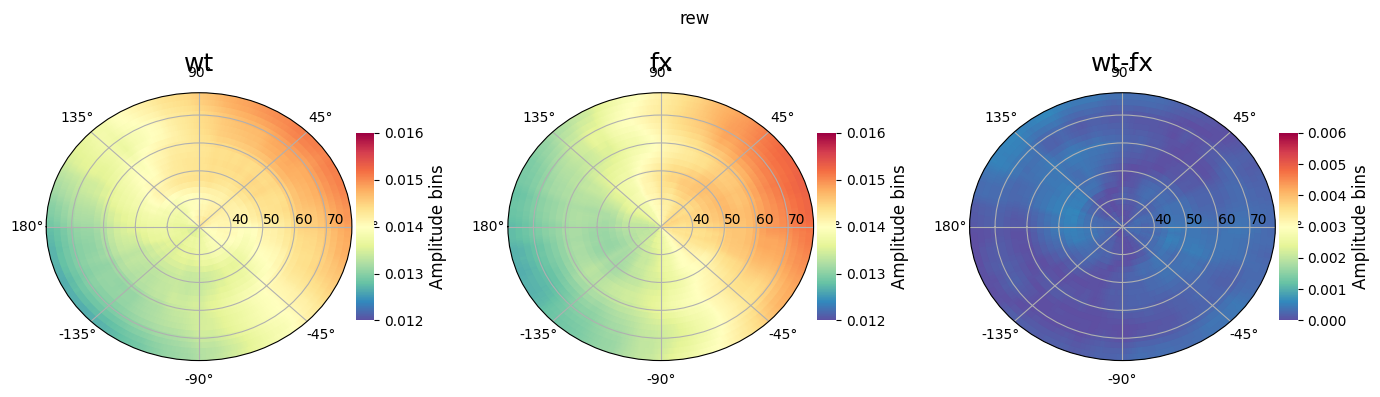

In [42]:
plt.rcdefaults()

plt.figure(figsize=(14, 4))
pp_obj.polar(pp2_rew_wt, vb_rew_wt, po_rew_wt.yvec, subplot=131, title='wt', **kw_plt9)
pp_obj.polar(pp2_rew_fx, vb_rew_fx, po_rew_fx.yvec, subplot=132, title='fx', **kw_plt9)
pp_obj.polar(rew_diff, vb_rew_wt, po_rew_wt.yvec, subplot=133, title='wt-fx', **kw_plt99)
plt.suptitle('rew')
plt.tight_layout()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\rew_PAC_radial.pdf", transparent=True)

plt.show()

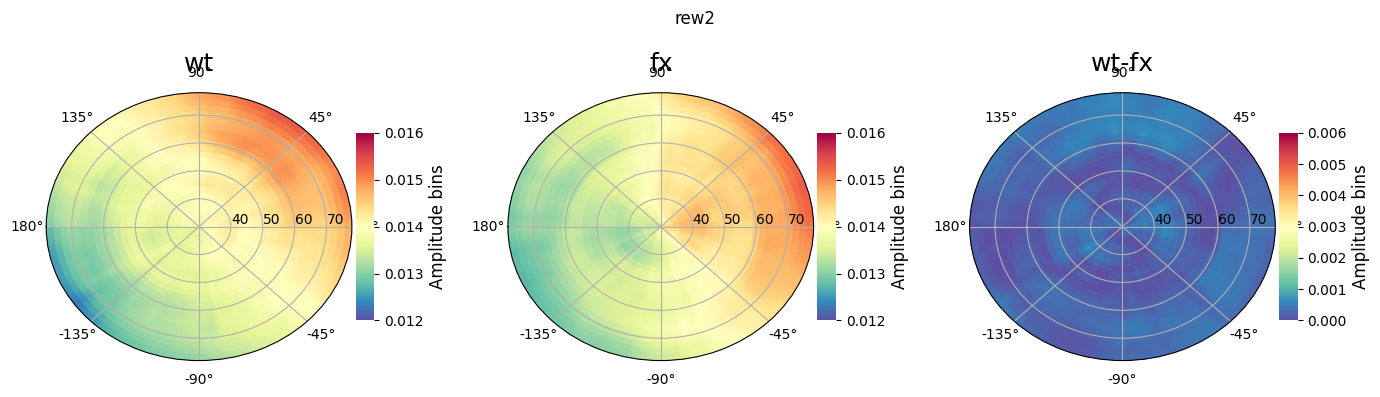

In [43]:
plt.figure(figsize=(14, 4))
pp_obj.polar(pp2_rew2_wt, vb_rew2_wt, po_rew2_wt.yvec, subplot=131, title='wt', **kw_plt9)
pp_obj.polar(pp2_rew2_fx, vb_rew2_fx, po_rew2_fx.yvec, subplot=132, title='fx', **kw_plt9)
pp_obj.polar(rew2_diff, vb_rew2_wt, po_rew2_wt.yvec, subplot=133, title='wt-fx', **kw_plt99)
plt.suptitle('rew2')
plt.tight_layout()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\rew2_PAC_radial.pdf", transparent=True)

plt.show()

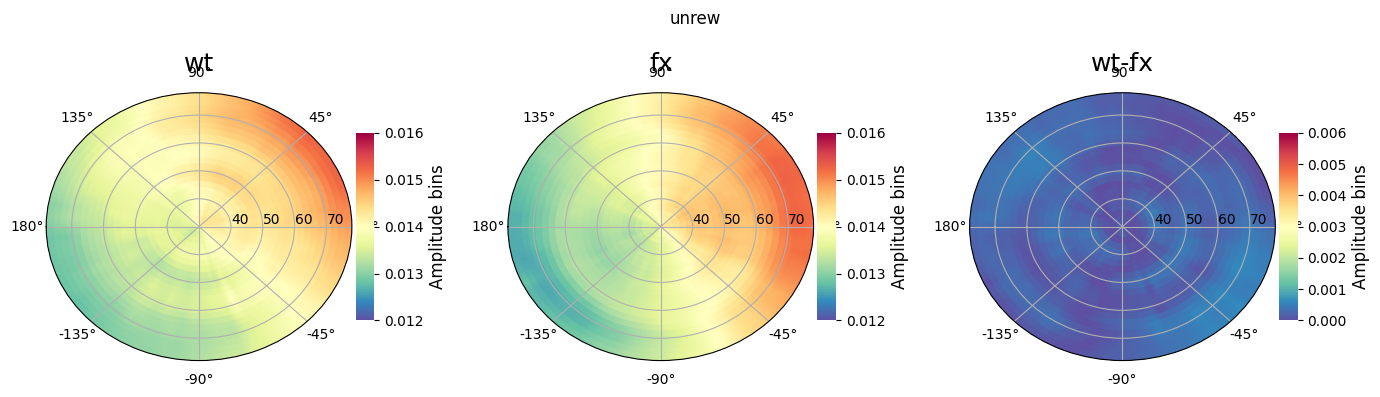

In [44]:
plt.figure(figsize=(14, 4))
pp_obj.polar(pp2_unrew_wt, vb_unrew_wt, po_unrew_wt.yvec, subplot=131, title='wt', **kw_plt9)
pp_obj.polar(pp2_unrew_fx, vb_unrew_fx, po_unrew_fx.yvec, subplot=132, title='fx', **kw_plt9)
pp_obj.polar(unrew_diff, vb_unrew_wt, po_unrew_wt.yvec, subplot=133, title='wt-fx', **kw_plt99)
plt.suptitle('unrew')
plt.tight_layout()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\unrew_PAC_radial.pdf", transparent=True)

plt.show()

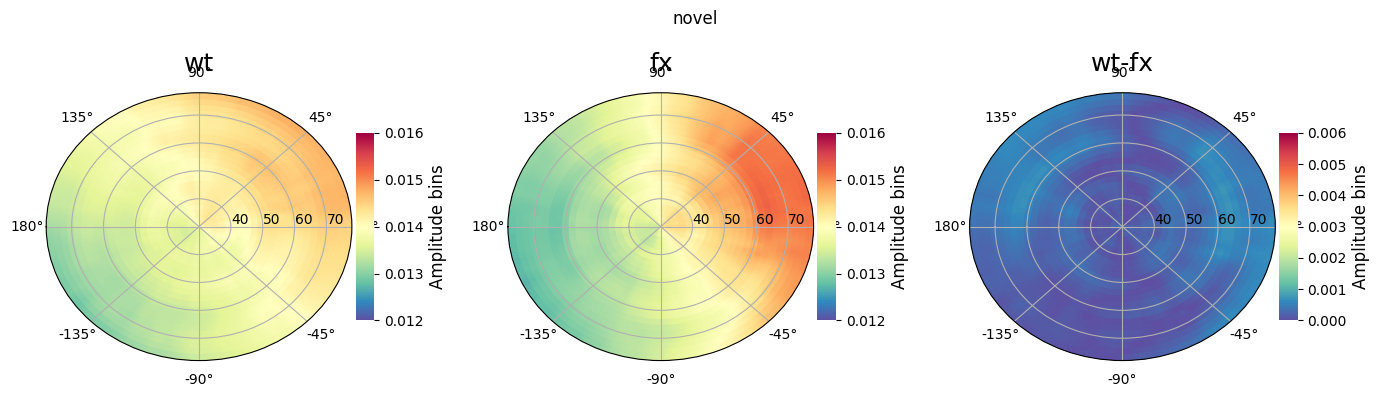

In [45]:
plt.figure(figsize=(14, 4))
pp_obj.polar(pp2_novel_wt, vb_novel_wt, po_novel_wt.yvec, subplot=131, title='wt', **kw_plt9)
pp_obj.polar(pp2_novel_fx, vb_novel_fx, po_novel_fx.yvec, subplot=132, title='fx', **kw_plt9)
pp_obj.polar(novel_diff, vb_novel_wt, po_novel_wt.yvec, subplot=133, title='wt-fx', **kw_plt99)
plt.suptitle('novel')
plt.tight_layout()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\novel_PAC_radial.pdf", transparent=True)

plt.show()